<a href="https://colab.research.google.com/github/Sambarlasagna/ComputerVision_Pytorch/blob/main/ptorch_custom_datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import torch
from torch import nn
torch.__version__
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device )

cuda


In [7]:
#Get data
import requests
import zipfile
from pathlib import Path

#Setup to a data folder
data_path = Path("data/")
image_path = data_path/"pizza_steak_sushi"

#if the image folder doest exist, download it and prepre it....
if image_path.is_dir():
  print(f"{image_path} directory already exists... skipping download")
else:
  print(f"Did not find {image_path} directory,creating one...")
  image_path.mkdir(parents=True,exist_ok = True)

#download pizza,steak and sushi data
with open(data_path / "pizza_steak_sushi.zip","wb") as f:
  request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
  print("Downloading data..")
  f.write(request.content)
#unzip file
with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip","r") as zip_ref:
  print("Unziping pizza,steak and sushi data...")
  zip_ref.extractall(image_path)

Did not find data/pizza_steak_sushi directory,creating one...
Unziping pizza,steak and sushi data...


### data prep and exploration


In [8]:
import os
def walk_through_dir(dir_path):
  for dirpath,dirnames,filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'")
walk_through_dir(image_path)


There are 2 directories and 0 images in 'data/pizza_steak_sushi'
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'


In [9]:
#setup train and testing paths
train_dir = image_path /"train"
test_dir = image_path/"test"

train_dir,test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

Random image path:data/pizza_steak_sushi/train/pizza/1968947.jpg
Image class:pizza
Image height:512
Image width: 512


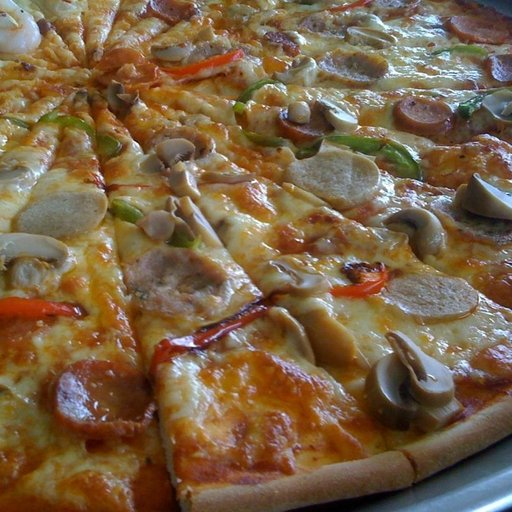

In [10]:
import random
from PIL import Image

# random.seed(42)

image_path_list = list(image_path.glob("*/*/*.jpg"))

random_image_path = random.choice(image_path_list)

image_class = random_image_path.parent.stem

img = Image.open(random_image_path)

print(f"Random image path:{random_image_path}")
print(f"Image class:{image_class}")
print(f"Image height:{img.height}")
print(f"Image width: {img.width}")
img

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

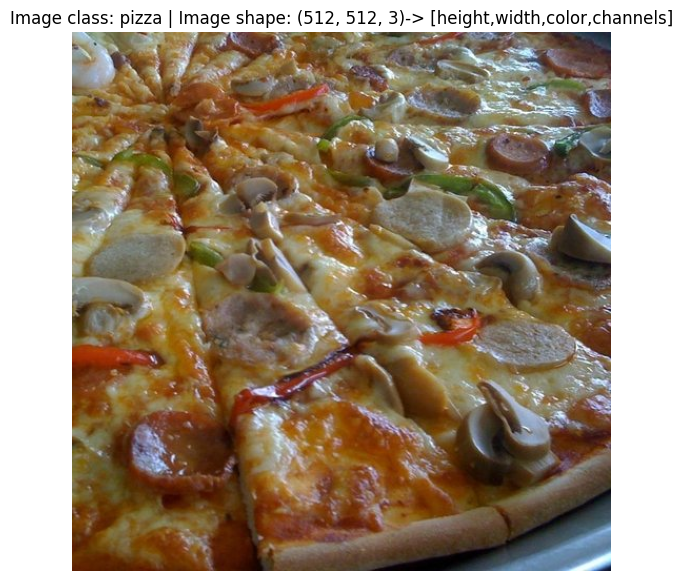

In [11]:
import numpy as np
import matplotlib.pyplot as plt

img_as_array = np.asarray(img)

plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape}-> [height,width,color,channels]")
plt.axis(False)

array([[[172, 181, 176],
        [172, 183, 177],
        [173, 186, 179],
        ...,
        [ 33,  39,  61],
        [ 30,  38,  61],
        [ 28,  39,  61]],

       [[169, 178, 173],
        [170, 181, 175],
        [172, 185, 178],
        ...,
        [ 34,  40,  62],
        [ 30,  41,  63],
        [ 30,  41,  63]],

       [[170, 176, 172],
        [171, 180, 175],
        [173, 184, 180],
        ...,
        [ 32,  40,  59],
        [ 29,  40,  60],
        [ 29,  42,  61]],

       ...,

       [[ 92,  31,   2],
        [ 93,  32,   3],
        [ 94,  33,   2],
        ...,
        [ 18,  34,  67],
        [ 16,  29,  61],
        [ 15,  29,  58]],

       [[ 92,  31,   2],
        [ 93,  32,   3],
        [ 94,  33,   4],
        ...,
        [ 15,  25,  52],
        [ 13,  23,  48],
        [ 14,  24,  49]],

       [[ 93,  32,   3],
        [ 93,  32,   3],
        [ 93,  32,   3],
        ...,
        [ 18,  24,  48],
        [ 13,  21,  42],
        [ 13,  21,  42]]], dtype=uint8)
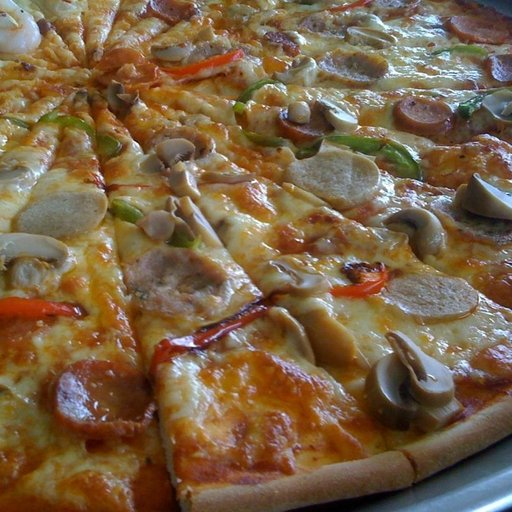

In [12]:
img_as_array

In [13]:
#3. Transforming data
import torch
from torch.utils.data import DataLoader
from torchvision import datasets,transforms

In [14]:
#Write transform for image
data_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
    ])

In [15]:
data_transform(img)

tensor([[[0.6510, 0.6431, 0.5725,  ..., 0.1843, 0.1529, 0.1373],
         [0.5765, 0.6235, 0.6118,  ..., 0.2471, 0.2235, 0.1922],
         [0.5490, 0.6196, 0.6392,  ..., 0.2980, 0.2824, 0.2353],
         ...,
         [0.3686, 0.3804, 0.3922,  ..., 0.3843, 0.4039, 0.4627],
         [0.3922, 0.3765, 0.3686,  ..., 0.5294, 0.6863, 0.7255],
         [0.3765, 0.3686, 0.3529,  ..., 0.8000, 0.6196, 0.3608]],

        [[0.7020, 0.7333, 0.6549,  ..., 0.2196, 0.2078, 0.1843],
         [0.5608, 0.6392, 0.6627,  ..., 0.1961, 0.2196, 0.2235],
         [0.5843, 0.6392, 0.6392,  ..., 0.2000, 0.1882, 0.1725],
         ...,
         [0.1647, 0.1882, 0.2235,  ..., 0.5176, 0.5373, 0.6118],
         [0.1843, 0.1686, 0.1647,  ..., 0.6627, 0.8157, 0.8824],
         [0.1451, 0.1373, 0.1333,  ..., 0.9059, 0.7569, 0.4902]],

        [[0.6824, 0.7529, 0.6039,  ..., 0.2902, 0.2745, 0.2510],
         [0.4941, 0.5569, 0.6353,  ..., 0.2314, 0.2784, 0.2902],
         [0.5725, 0.5686, 0.5686,  ..., 0.1922, 0.1961, 0.

In [16]:
def plot_transformed_images(image_paths: list,transform,n=3,seed=None):
  if seed:
    random.seed(seed)
  random_image_paths = random.sample(image_paths,k=n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(nrows=1,ncols=2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original\nSize: {f.size}")
      ax[0].axis(False)

      transformed_image = transform(f).permute(1,2,0)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
      ax[1].axis("off")

      fig.suptitle(f"Class: {image_path.parent.stem}",fontsize=16)

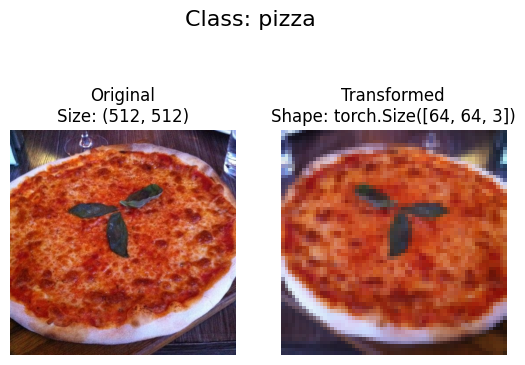

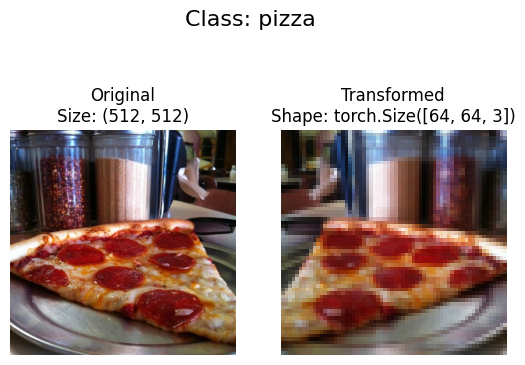

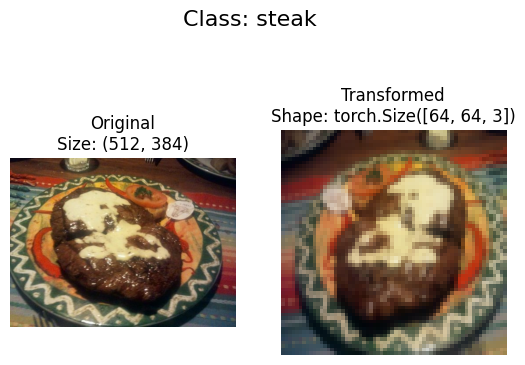

In [17]:
plot_transformed_images(image_path_list,
                        data_transform,3,42 )

In [18]:
#use ImageFolder to create dataset(s)
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,transform=data_transform,
                                  target_transform=None)
test_data = datasets.ImageFolder(root=test_dir,
                                 transform = data_transform)
train_data,test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [19]:
class_names = train_data.classes
class_dict = train_data.class_to_idx
class_names,class_dict

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [20]:
len(train_data),train_data.samples[0],len(test_data),test_data.samples[0]

(225,
 ('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0),
 75,
 ('data/pizza_steak_sushi/test/pizza/1152100.jpg', 0))

In [21]:
img,label = train_data[0][0],train_data[0][1]
print(f"Image tensor:\n {img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Image class: {class_names[label]}")
print(f"Label datatype: {type(label)}")

Image tensor:
 tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
         [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
         [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
         ...,
         [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
         [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
         [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],

        [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
         [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
         [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
         ...,
         [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
         [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
         [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],

        [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
         [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
         [0.0902, 0.0902, 0.0902,  ..., 0.0

Original shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Image permute shape: torch.Size([64, 64, 3]) -> [height, width, color_channels]


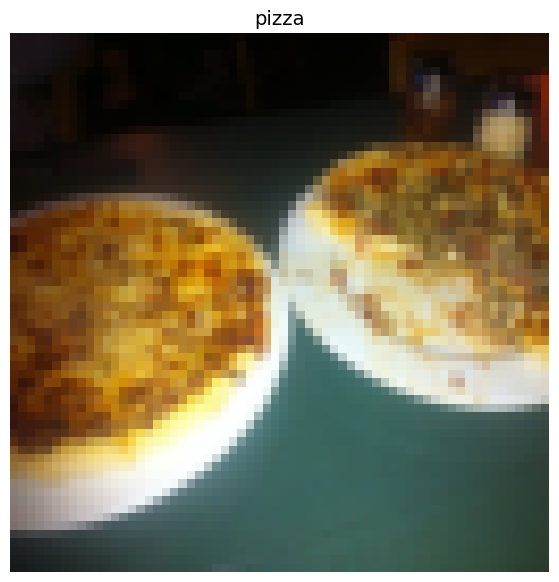

In [22]:
# Rearrange the order of dimensions
img_permute = img.permute(1, 2, 0)

# Print out different shapes (before and after permute)
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permute shape: {img_permute.shape} -> [height, width, color_channels]")

# Plot the image
plt.figure(figsize=(10, 7))
plt.imshow(img.permute(1, 2, 0))
plt.axis("off")
plt.title(class_names[label], fontsize=14);

In [23]:
import os
os.cpu_count()

2

In [24]:
from torch.utils.data import DataLoader
BATCH_SIZE=32
train_dataloader = DataLoader(dataset = train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=1,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size =BATCH_SIZE,
                             shuffle=False)
print(len(train_dataloader),len(test_dataloader))
len(train_data),len(test_data)

8 3


(225, 75)

In [25]:
img,label = next(iter(train_dataloader))
print(f"Image shape: {img.shape} -> [batch_size,color_channels,height,width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([32, 3, 64, 64]) -> [batch_size,color_channels,height,width]
Label shape: torch.Size([32])


#3 Loading Image Data with a Custom `Dataset`

In [26]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple,Dict, List



In [27]:
train_data.classes,train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [28]:
#5.1 Creatingn a helper function to get class names
target_directory = train_dir
print(f"Target dir: {target_directory}")

class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_found



Target dir: data/pizza_steak_sushi/train


['pizza', 'steak', 'sushi']

In [29]:
def find_classes(directory:str)-> Tuple[List[str], Dict[str,int]]:
  classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

  if not classes:
    raise FileNotFoundError(f"Couldn't find any classes in {directory}")
  class_to_idx = {cls_name:i for i,cls_name in enumerate(classes)}
  return classes,class_to_idx
find_classes(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [30]:
from torch.utils.data import Dataset
class ImageFolderCustom(Dataset):
    def __init__(self,
                targ_dir:str,transform=None):
     self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
     self.transform = transform
     self.classes,self.class_to_idx = find_classes(targ_dir)

    def load_image(self,index: int)->Image.Image:
      image_path = self.paths[index]
      return Image.open(image_path)

    def __len__(self)->int:
      return len(self.paths)

    def __getitem__(self,index:int)->Tuple[torch.Tensor, int]:
      img = self.load_image(index)
      class_name = self.paths[index].parent.name
      class_idx = self.class_to_idx[class_name]

      if self.transform:
        return self.transform(img), class_idx
      else:
        return img,class_idx


In [31]:
from torchvision import transforms
train_transforms = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

In [32]:
train_data_custom = ImageFolderCustom(targ_dir = train_dir,
                                      transform = train_transforms)
test_data_custom = ImageFolderCustom(targ_dir = test_dir,
                                    transform = test_transforms)

In [33]:
train_data_custom,test_data_custom

(<__main__.ImageFolderCustom at 0x7f9ff5796ab0>,
 <__main__.ImageFolderCustom at 0x7f9ff589a120>)

In [34]:
len(train_data),len(train_data_custom)

(225, 225)

In [35]:
len(test_data),len(test_data_custom)

(75, 75)

In [36]:
test_data_custom.classes,test_data_custom.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [37]:
#Check for equality
print(train_data_custom.classes==train_data.classes)
print(test_data_custom.classes==test_data.classes)

True
True


### 5.3 Create a function to display random images

In [38]:
#5.3 Create a function to display random images
def display_random_images(dataset:torch.utils.data.Dataset,
                          classes:List[str]=None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int= None):
  if n>10:
    n = 10
    display_shape = False
    print(f"For display, purposes, shudnt be larger than 10, setting to 10 and removign shape display")

  if seed:
    random.seed (seed)

  random_samples_idx = random.sample(range(len(dataset)),k=n)

  plt.figure(figsize=(16,8))

  for i,targ_sample in enumerate(random_samples_idx):
    targ_image,targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

    targ_image_adjust = targ_image.permute(1,2,0) #from chw to hwc

    plt.subplot(1,n,i+1) # Changed n/2 to (n+1)//2 to handle odd n
    plt.imshow(targ_image_adjust)
    if classes:
      title = f"Class: {classes[targ_label]}\n"
      if display_shape:
        title = title + f"Shape: {targ_image_adjust.shape}"
      plt.title(title)
      plt.axis("off")

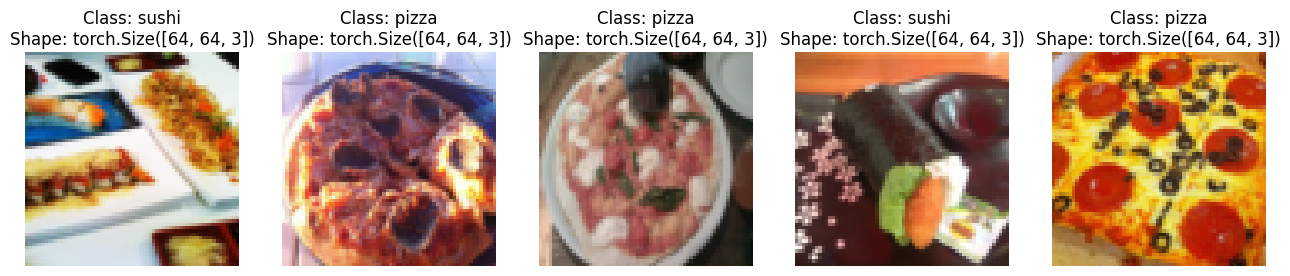

In [39]:
display_random_images(train_data,
                      n=5,
                      classes=class_names,
                      seed=42)


For display, purposes, shudnt be larger than 10, setting to 10 and removign shape display


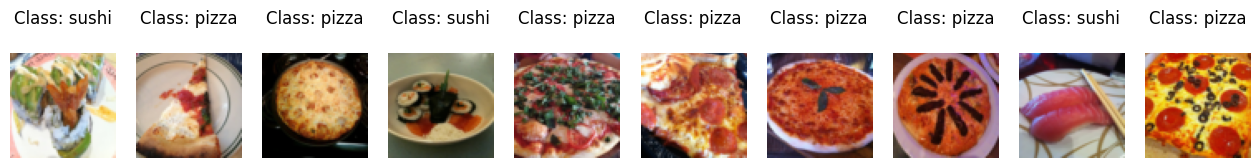

In [40]:
display_random_images(train_data_custom,
                      n=20,
                      classes=class_names,
                      seed=42)

### 5.4 Turn custom laded images into `DataLoader`'s

In [41]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()
train_dataloader_custom = DataLoader(dataset = train_data_custom,
                                     batch_size = BATCH_SIZE,
                                     num_workers = NUM_WORKERS,
                                     shuffle = True)
test_dataloader_custom = DataLoader(dataset = test_data_custom,
                                    batch_size = BATCH_SIZE,
                                    num_workers = NUM_WORKERS,
                                    shuffle = False)
train_dataloader_custom,test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x7f9ff547df40>,
 <torch.utils.data.dataloader.DataLoader at 0x7f9ff5796870>)

In [42]:
#Get image and label from customddataloader
img_custom,label_custom = next(iter(train_dataloader_custom))

#print out the shapes
img_custom.shape,label_custom.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

### Data augmentation



In [43]:
from torchvision import transforms

train_transform = transforms.Compose([ transforms.Resize(size=(224,224)),
                                        transforms.TrivialAugmentWide(num_magnitude_bins=31),
                                        transforms.ToTensor()
])
test_transform = transforms.Compose([transforms.Resize(size=(224,224)),
                                      transforms.ToTensor()
])

In [44]:
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[PosixPath('data/pizza_steak_sushi/train/pizza/2426686.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/138855.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/1633289.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/218711.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/220190.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/3860002.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/3196721.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/1089334.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/300869.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/2428085.jpg')]

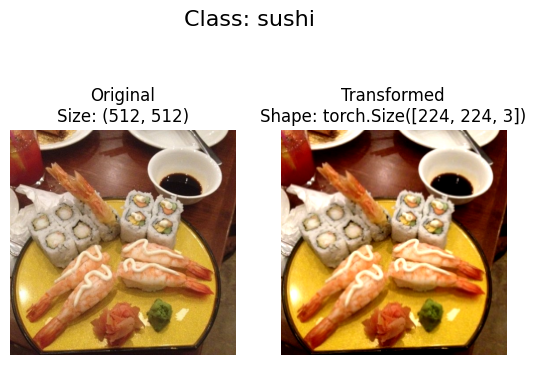

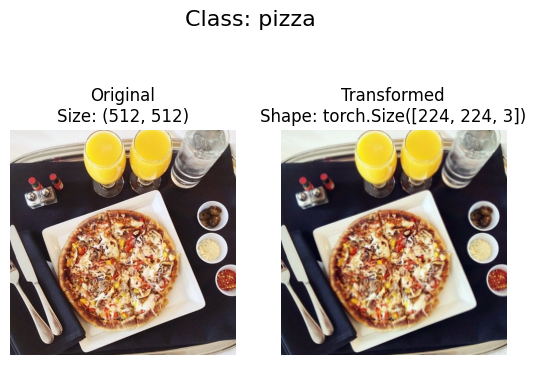

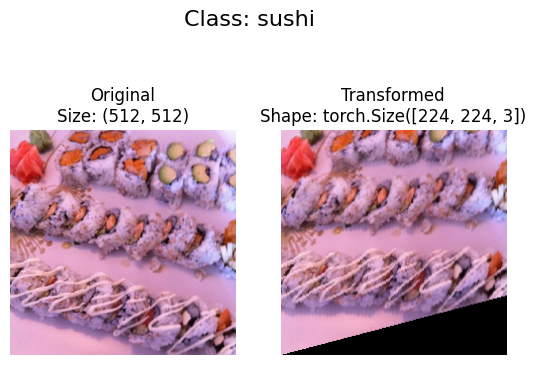

In [45]:
plot_transformed_images(image_paths = image_path_list,
                          transform = train_transform,
                          n=3,
                          seed=None)

#7 : Model 0- TinyVGG withotu data augmentation
https://poloclub.github.io/cnn-explainer/

In [46]:
#7.1 Creating transforms and llading data for Model 0
from torchvision import transforms
simple_transform = transforms.Compose([transforms.Resize(size=(64,64)),
                                       transforms.ToTensor()
])

In [47]:
#load and transform data
from torchvision import datasets
train_data_simple = datasets.ImageFolder(root=train_dir,
                                         transform=simple_transform)
test_data_simple = datasets.ImageFolder(root=test_dir,
                                        transform = simple_transform)
#turn the datasets into DataLoaders
import os
from torch.utils.data import DataLoader

BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

#create dataLoader's
train_dataloader_simple = DataLoader(dataset = train_data_simple,
                                     batch_size = BATCH_SIZE,
                                     shuffle = True,
                                     num_workers = NUM_WORKERS)
test_dataloader_simple = DataLoader(dataset = test_data_simple,
                                     batch_size = BATCH_SIZE,
                                     shuffle = False,
                                     num_workers = NUM_WORKERS)

### 7.2 Create TinyVGG model class


In [48]:
class TinyVGG(nn.Module):
  def __init__(self,input_shape: int,
               hidden_units: int,
               output_shape:int)->None:
      super().__init__()
      self.conv_block_1 = nn.Sequential(
          nn.Conv2d(in_channels =input_shape,
                    out_channels =hidden_units,
                    kernel_size = 3,
                    stride = 1,
                    padding = 0),
          nn.ReLU(),
          nn.Conv2d(in_channels=hidden_units,
                    out_channels=hidden_units,
                    kernel_size = 3,
                    stride  =1,
                    padding = 0 ),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size = 2,
                       stride = 2),
      )
      self.conv_block_2 = nn.Sequential(
          nn.Conv2d(in_channels =hidden_units,
                    out_channels =hidden_units,
                    kernel_size = 3,
                    stride = 1,
                    padding = 0),
          nn.ReLU(),
          nn.Conv2d(in_channels=hidden_units,
                    out_channels=hidden_units,
                    kernel_size = 3,
                    stride  =1,
                    padding = 0 ),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size = 2,
                       stride = 2)
      )
      self.classifier = nn.Sequential(
          nn.Flatten(),
          nn.Linear(in_features = hidden_units*13*13,
                    out_features = output_shape)
      )

  def forward(self,x):
    x = self.conv_block_1(x)
    # print(x.shape)
    x = self.conv_block_2(x)
    # print(x.shape)
    x = self.classifier(x)
    # print(x.shape)
    return x
    # return self.classifier(self.conv_block_2(self.conv_block_1(x)))


In [49]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape = 3, #number of colour channels
                  hidden_units = 10,
                  output_shape = len(class_names)).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

In [50]:
# 7.3 try a forward a pass on a single image to test the model
image_batch,label_batch = next(iter(train_dataloader_simple))
image_batch.shape,label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [52]:
#try a forward pass
model_0(image_batch.to(device))

tensor([[ 2.0795e-02, -1.9510e-03,  9.5212e-03],
        [ 1.8440e-02,  2.4669e-03,  6.6609e-03],
        [ 1.7695e-02,  1.0282e-03,  9.4975e-03],
        [ 2.4446e-02, -3.3489e-03,  9.5877e-03],
        [ 1.9939e-02,  6.9129e-04,  1.0778e-02],
        [ 2.1281e-02,  2.0434e-03,  5.0046e-03],
        [ 2.0996e-02,  1.6417e-04,  1.2481e-02],
        [ 2.1566e-02, -1.9607e-03,  9.7175e-03],
        [ 2.4500e-02, -4.7904e-03,  8.5394e-03],
        [ 2.0239e-02, -4.7980e-04,  1.0907e-02],
        [ 2.2219e-02, -4.1815e-04,  9.8173e-03],
        [ 2.2318e-02, -2.1642e-03,  9.4428e-03],
        [ 2.1851e-02, -3.7225e-03,  8.3784e-03],
        [ 2.2881e-02, -1.7559e-03,  1.0299e-02],
        [ 2.1635e-02, -4.3994e-03,  9.4990e-03],
        [ 2.2101e-02, -4.1469e-03,  9.3904e-03],
        [ 2.1226e-02, -4.4215e-03,  1.1476e-02],
        [ 2.1698e-02, -2.7458e-03,  8.4966e-03],
        [ 1.9974e-02, -3.2317e-07,  8.4496e-03],
        [ 1.8308e-02,  1.6378e-03,  8.5491e-03],
        [ 2.0768e-02

In [56]:
try:
  import torchinfo
except:
  !pip install torchinfo
  import torch

In [57]:
from torchinfo import summary
summary(model_0,input_size = (1,3,64,64))

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─ReLU: 2-4                         [1, 10, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 28, 28]           910
│    └─ReLU: 2-7                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 10, 26, 26]           910
│    └─ReLU: 2-9                         [1, 10, 26, 26]           --
│    └─MaxPool2d: 2-10                   [1, 10, 13, 13]           --
├─Sequentia

### 7.5 create train and test loop funcs


In [58]:
from re import L
def train_step(model : torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device : torch.device = device):
  model.train()
  train_loss,train_acc = 0,0
  model.to(device)
  for batch,(X,y) in enumerate (data_loader):
    X, y = X.to(device), y.to(device)

    #forward pass
    y_pred = model(X)

    #calc loss
    loss=loss_fn(y_pred,y)
    train_loss +=loss.item()

    #optimizer zero grad
    optimizer.zero_grad()

    #loss backward
    loss.backward()

    #optimizer step
    optimizer.step()

    #calc accuracy metric
    y_pred_class = torch.argmax(torch.softmax(y_pred,dim=1),dim=1)
    train_acc +=(y_pred_class==y).sum().item()/len(y_pred)

  #calc loss and acc per epoch and print out whats happeneing
  train_loss /=len(data_loader)
  train_acc /=len(data_loader)
  return train_loss,train_acc

def test_step(data_loader: torch.utils.data.DataLoader,
              model:torch.nn.Module,
              loss_fn: torch.nn.Module,
              device: torch.device = device):
  test_loss,test_acc = 0,0
  model.to(device)
  model.eval()

  with torch.inference_mode():

    for X,y in data_loader:
      X,y = X.to(device),y.to(device)

      #forward pass
      test_pred = model(X)

      #calc loss
      loss = loss_fn(test_pred,y)
      test_loss+=loss.item()

      #calc acc
      test_pred_labels = test_pred.argmax(dim=1)
      test_acc += ((test_pred_labels==y).sum().item()/len(test_pred_labels))

    #adjust metrics and print out
    test_loss/=len(data_loader)
    test_acc /=len(data_loader)
    return test_loss,test_acc

### 7.6 creating `train()` func to combine `train_step()` and `test_step()`

In [70]:
from tqdm.auto import tqdm
#create a func that takes in  various model parameters
def train(model:torch.nn.Module,
          train_dataloader:torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn =nn.CrossEntropyLoss(),
          epochs: int = 5,
          device=device):
  #create empty results dict
  results = {"train_loss":[],
             "train_acc":[],
             "test_loss":[],
             "test_acc":[]}
  #loop thru train and test steps for a number of steps
  for epoch in tqdm(range(epochs)):
    train_loss,train_acc = train_step(model = model,
                                      data_loader = train_dataloader,
                                      loss_fn = loss_fn,
                                      optimizer = optimizer,
                                      device = device)
    test_loss,test_acc = test_step(data_loader = test_dataloader,
                                   model = model,
                                   loss_fn = loss_fn,
                                   device = device)
    #print out
    print(f"Epoch: {epoch} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    #update results dict
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)

    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  return results

### 7.7 train and evaluate model 0


In [71]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

#set no. of epochs
NUM_EPOCHS = 5

#Recreate an instance of TinyVGG
model_0 = TinyVGG(input_shape = 3,
                  hidden_units = 10,
                  output_shape = len(train_data.classes)).to(device)
#setup loss func and optim
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),
                             lr = 0.001) # Reduced learning rate

#start the timer
from timeit import default_timer as timer
start_time = timer()

#trai model_0
model_0_results = train(model = model_0,
                        train_dataloader = train_dataloader_simple,
                        test_dataloader = test_dataloader_simple,
                        optimizer = optimizer,
                        loss_fn = loss_fn,
                        epochs = NUM_EPOCHS)
#end timer and print
end_time = timer()
print(f"Total training time: {end_time-start_time: .3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Train Loss: 1.1063 | Train Acc: 0.3047 | Test Loss: 1.0983 | Test Acc: 0.3011
Epoch: 1 | Train Loss: 1.0998 | Train Acc: 0.3281 | Test Loss: 1.0697 | Test Acc: 0.5417
Epoch: 2 | Train Loss: 1.0869 | Train Acc: 0.4883 | Test Loss: 1.0808 | Test Acc: 0.4924
Epoch: 3 | Train Loss: 1.0845 | Train Acc: 0.4023 | Test Loss: 1.0607 | Test Acc: 0.5833
Epoch: 4 | Train Loss: 1.0663 | Train Acc: 0.4180 | Test Loss: 1.0659 | Test Acc: 0.5644
Total training time:  4.469 seconds


In [72]:
model_0_results

{'train_loss': [1.1063201278448105,
  1.0998032987117767,
  1.086855709552765,
  1.0844951421022415,
  1.0662740916013718],
 'train_acc': [0.3046875, 0.328125, 0.48828125, 0.40234375, 0.41796875],
 'test_loss': [1.0983194907506306,
  1.0696600675582886,
  1.0807691017786663,
  1.0606525739034016,
  1.065880258878072],
 'test_acc': [0.30113636363636365,
  0.5416666666666666,
  0.49242424242424243,
  0.5833333333333334,
  0.5643939393939394]}

### 7.8 plot the loss curves od model 0


In [73]:
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [74]:
from typing import Dict, List
import matplotlib.pyplot as plt

def plot_loss_curves(results : Dict[str,List[float]]):
  #get thr loss vlaues frm the res dict
  loss = results["train_loss"]
  test_loss = results["test_loss"]

  accuracy = results["train_acc"]
  test_accuracy = results["test_acc"]

  epochs = range(len(results["train_loss"]))

  #setup a plot

  plt.figure(figsize=(15,7))

  #plot loss

  plt.subplot(1,2,1)
  plt.plot(epochs,loss,label = "train_loss")
  plt.plot(epochs,test_loss,label = "test_loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.legend()

  #plot accuracy
  plt.subplot(1,2,2)
  plt.plot(epochs,accuracy,label = "train_accuracy")
  plt.plot(epochs,test_accuracy,label = "test_accuracy")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.legend()

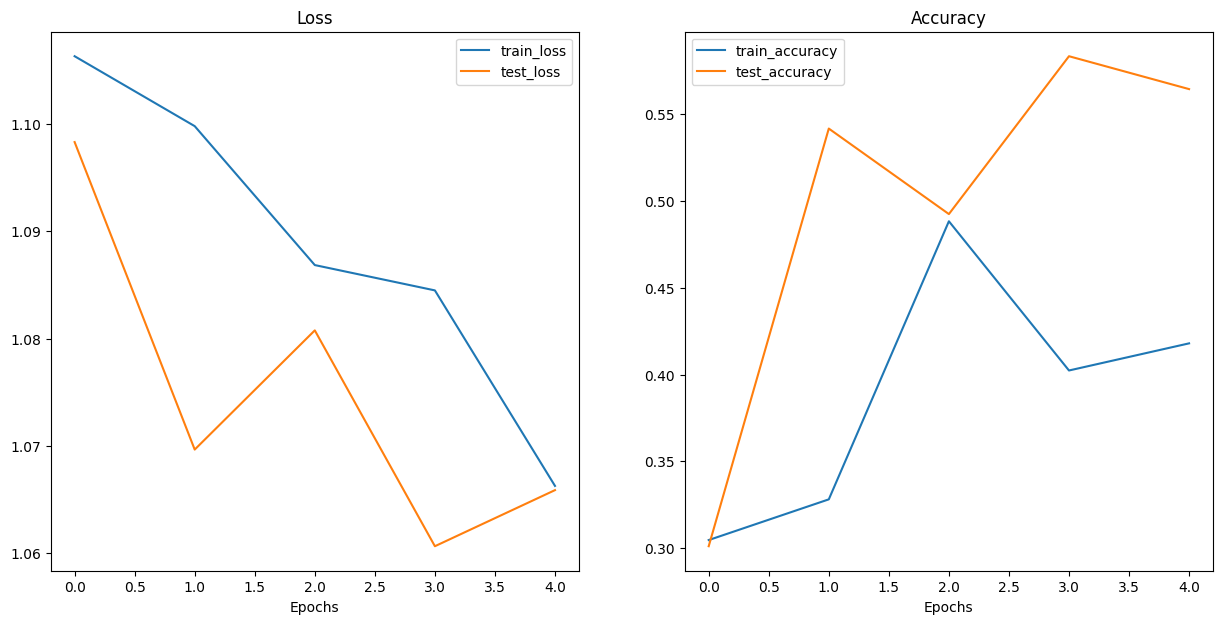

In [75]:
plot_loss_curves(model_0_results)